> ## MODEL LAMA (v1, 11 kelas) -- notebook backup, TERISOLASI dari training baru
>
> Notebook ini sudah dimodifikasi supaya **aman dijalankan ulang kapan saja**: checkpoint & katalog di-load dari `checkpoints/v1_11class_backup/` dan `data/cache/v1_11class_backup/` (bukan path live `checkpoints/best.pth` / `data/cache/catalog_embeddings.npz` yang sekarang dipakai model BARU). Menjalankan ulang cell di sini TIDAK akan menampilkan hasil model baru, dan TIDAK akan menimpa file live manapun.
>
> Untuk demo model TERBARU (setelah training 22-kelas selesai), pakai `notebooks/03_demo_inference.ipynb` yang asli, bukan file di folder ini.

# 03 — Demo Inference: scan 1 lukisan -> style + pelukis + info lengkap

Simulasi produk nyata: **1 gambar masuk** -> sistem keluarkan:
1. **Prediksi style** (dari classifier hasil training, `01_train.ipynb`) --
   ini tebakan model, akurasi ~78% (macam-macam style, lihat confusion matrix).
2. **Pencocokan ke katalog** (dari embedding, `02_embedding_retrieval.ipynb`)
   -- kalau lukisannya ADA di katalog kita, sistem menemukan entri persis itu
   dan mengembalikan **info sebenarnya** dari `metadata.csv`: nama pelukis,
   genre, style asli, tingkat kemiripan. Ini yang terbukti 90% akurat
   (instance retrieval) -- bukan tebakan, tapi pencocokan.

**Beda penting:** #1 = tebakan model (bisa salah, terutama utk style yang
sering ter-confuse, lihat `01_train.ipynb`). #2 = pencocokan nyata ke database
katalog (kalau similarity tinggi, itu KEMUNGKINAN BESAR lukisan yang sama;
kalau similarity rendah, cuma "yang paling mirip yang kita punya", BUKAN
berarti itu lukisannya).

> **Kernel wajib ada `torch`.** Prasyarat: `checkpoints/best.pth` dan
> `data/cache/catalog_embeddings.npz` sudah ada (jalankan `01_train.ipynb`
> lalu `02_embedding_retrieval.ipynb` dulu kalau belum).

## 1. Setup

In [12]:
%matplotlib inline
import os, sys
from pathlib import Path

_p = Path.cwd()
while not ((_p / "src").is_dir() and (_p / "configs").is_dir()):
    if _p == _p.parent:
        raise RuntimeError("folder ml/ (berisi src/ & configs/) tidak ketemu")
    _p = _p.parent
os.chdir(_p)
if str(_p) not in sys.path:
    sys.path.insert(0, str(_p))

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

print("working dir:", os.getcwd())
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

working dir: c:\Users\thori\Downloads\Semester 5\projek galeria\ml-visual-search
torch: 2.14.0+cu130 | CUDA: True


## 2. Muat model + checkpoint + katalog

In [13]:
from src.utils import get_device, resolve_path
from src.model import build_model, load_checkpoint
from src.transforms import build_eval_transforms
from src.embedding import nearest_neighbors, confidence_verdict

CKPT_PATH = "checkpoints/v1_11class_backup/last.pth"
CATALOG_PATH = "data/cache/v1_11class_backup/catalog_embeddings.npz"

# checkpoint lama menyimpan config & label_to_idx miliknya SENDIRI (snapshot saat
# training v1) -- sengaja TIDAK load configs/config.yaml yang sekarang, karena itu
# sudah berubah untuk model baru (22 kelas, data 33,9k gambar).
_raw = torch.load(resolve_path(CKPT_PATH), map_location="cpu", weights_only=False)
cfg = _raw["config"]
label_to_idx = _raw["label_to_idx"]
idx_to_label = {v: k for k, v in label_to_idx.items()}
num_classes = len(label_to_idx)

device = get_device(cfg["device"])
eval_tf = build_eval_transforms(cfg)

model = build_model(cfg, num_classes=num_classes).to(device).eval()
ck = load_checkpoint(model, CKPT_PATH, map_location=str(device))
vm = ck["val_metrics"]
print(f"[MODEL LAMA v1 - {num_classes} kelas] {model.arch} | checkpoint epoch {ck.get('epoch')} "
      f"| val_macro_f1={vm['macro_f1']:.4f}")
print("  (dari last.pth, bukan best.pth -- best.pth v1 sudah tertimpa training baru sebelum sempat dibackup)")

# katalog LAMA (5.659 karya) -- terpisah total dari katalog live yang dipakai model baru
cat = np.load(resolve_path(CATALOG_PATH))
cat_emb, cat_fnames, cat_labels = cat["embeddings"], cat["filenames"], cat["labels"]
meta = pd.read_csv(resolve_path("data/raw/metadata.csv")).set_index("filename")
print(f"[KATALOG LAMA] {len(cat_fnames)} karya x {cat_emb.shape[1]}-d embedding")

[MODEL LAMA v1 - 11 kelas] convnext_small | checkpoint epoch 30 | val_macro_f1=0.7610
  (dari last.pth, bukan best.pth -- best.pth v1 sudah tertimpa training baru sebelum sempat dibackup)
[KATALOG LAMA] 5659 karya x 768-d embedding


## 3. Fungsi `scan_lukisan(image_path)` + `show_result(result)`

Dua fungsi inti: `scan_lukisan` mengerjakan prediksi + pencarian katalog, `show_result` menampilkannya (dipakai ulang oleh contoh manual & picker interaktif di bawah -- makanya didefinisikan di sini, sebelum dipakai).

In [14]:
IMAGE_DIR = resolve_path(cfg["data"]["image_dir"])  # data/processed/ (SquarePad sudah diterapkan)

def _predict_pil(img_pil, top_k=5, transform=None):
    # inti prediksi -- dipakai scan_lukisan (file) & live_scan (webcam), biar tidak duplikat logic
    tf = transform or eval_tf
    x = tf(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)                                    # klasifikasi style
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()
        feat = model.forward_features(x)                      # embedding utk retrieval
        if cfg["embedding"]["l2_normalize"]:
            feat = F.normalize(feat, dim=1)
        feat = feat.cpu().numpy()

    top3 = np.argsort(-probs)[:3]
    style_pred = [(idx_to_label[i], float(probs[i])) for i in top3]

    idxs, scores = nearest_neighbors(feat, cat_emb, top_k=top_k)
    verdict = confidence_verdict(scores[0])   # "confirmed" | "ambiguous" | "not_found"
    matches = []
    for gi, sim in zip(idxs[0], scores[0]):
        fn = str(cat_fnames[gi])
        row = meta.loc[fn] if fn in meta.index else None
        matches.append({
            "filename": fn, "similarity": float(sim),
            "artist_name": row["artist_name"] if row is not None else "?",
            "genre_name": row["genre_name"] if row is not None else "?",
            "style_name": row["style_name"] if row is not None else "?",
        })
    return {"input_image": img_pil, "style_prediction": style_pred,
            "catalog_matches": matches, "verdict": verdict}


def scan_lukisan(image_path, top_k=5):
    img = Image.open(image_path).convert("RGB")
    return _predict_pil(img, top_k=top_k)   # eval_tf: gambar dataset kita sudah persegi (preprocess)

In [15]:
_VERDICT_TEXT = {
    "confirmed": "-> KEMUNGKINAN BESAR karya yang sama (skor tinggi & menonjol jelas dari kandidat lain)",
    "ambiguous": "-> TIDAK PASTI: beberapa karya mirip, TIDAK ADA yang menonjol jelas -- jangan anggap #1 pasti benar",
    "not_found": "-> kemungkinan besar karya ini TIDAK ADA di katalog kami",
}

def show_result(result, save_path=None):
    matches = result["catalog_matches"]
    verdict = result.get("verdict", "ambiguous")
    fig, axes = plt.subplots(1, 1 + len(matches), figsize=(3.2 * (1 + len(matches)), 4))

    axes[0].imshow(result["input_image"]); axes[0].axis("off")
    top_style, top_p = result["style_prediction"][0]
    axes[0].set_title(f"INPUT\nprediksi: {top_style}\n({top_p*100:.0f}%)", fontsize=9, weight="bold")

    for i, m in enumerate(matches, start=1):
        mimg = Image.open(IMAGE_DIR / m["filename"]).convert("RGB")
        axes[i].imshow(mimg); axes[i].axis("off")
        # HANYA #1 boleh ditandai hijau "sama", dan HANYA kalau verdict="confirmed".
        # #2..#N (atau semua, kalau ambiguous/not_found) = "karya serupa", bukan klaim identitas.
        is_the_match = (i == 1 and verdict == "confirmed")
        color = "green" if is_the_match else "black"
        tag = " (INI)" if is_the_match else ""
        axes[i].set_title(f"#{i} sim={m['similarity']:.2f}{tag}\n{m['artist_name']}\n{m['style_name']}",
                          fontsize=8, color=color)

    fig.suptitle("Scan lukisan -> hasil pencarian katalog GALERIA", fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path or resolve_path("outputs/demo_scan_result.png"), dpi=110)
    plt.show()

    print("=== PREDIKSI STYLE ===")
    for style, p in result["style_prediction"]:
        print(f"  {style:24s} {p*100:5.1f}%")

    print(f"\n=== KECOCOKAN KATALOG ({verdict.upper()}) ===")
    print(f"  {_VERDICT_TEXT[verdict]}")
    if verdict == "ambiguous":
        artists = sorted({m["artist_name"] for m in matches})
        print(f"  kandidat pelukis: {', '.join(artists)}")
    for i, m in enumerate(matches, 1):
        flag = "<-- INI (kemungkinan besar sama)" if (i == 1 and verdict == "confirmed") else ""
        print(f"  #{i} sim={m['similarity']:.3f} | {m['artist_name']:22s} | "
              f"{m['style_name']:22s} | {m['genre_name']:18s} | {m['filename']} {flag}")

## 4. Coba dengan 1 gambar dari dataset kita

Ganti `IMAGE_PATH` dengan gambar mana saja -- dari dataset kita
(`data/raw/wikiart_XXXXX.jpg`, cek `metadata.csv` buat lihat nama filenya)
atau **gambar dari luar** (foto dari internet/HP, path lokal apa saja).

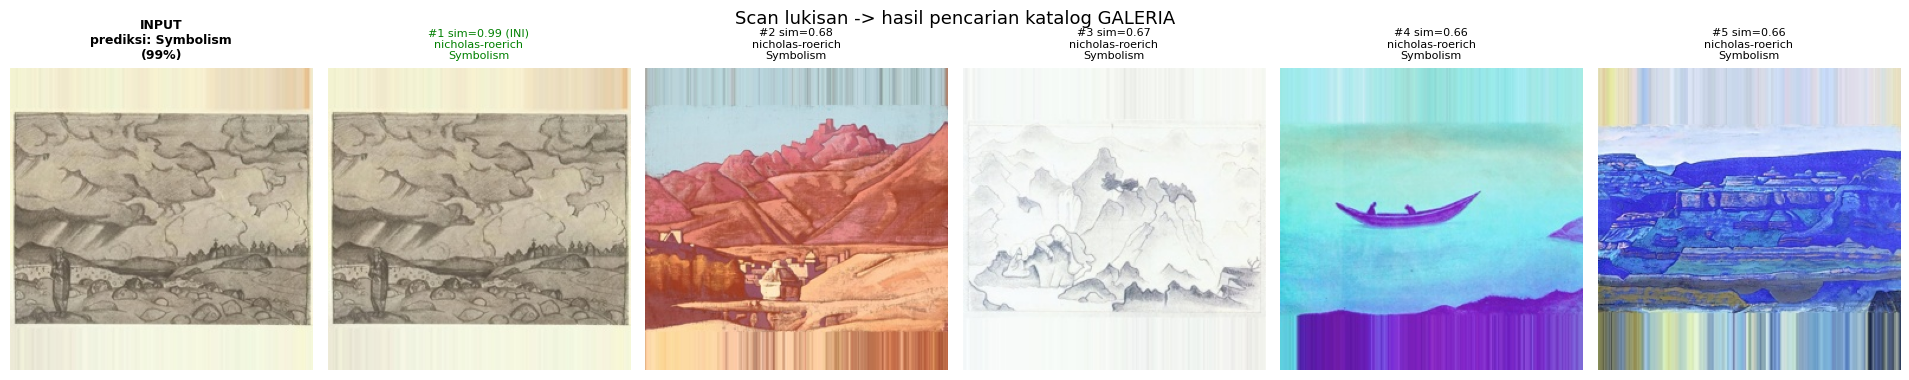

=== PREDIKSI STYLE ===
  Symbolism                 98.6%
  Post_Impressionism         0.2%
  Northern_Renaissance       0.2%

=== KECOCOKAN KATALOG (CONFIRMED) ===
  -> KEMUNGKINAN BESAR karya yang sama (skor tinggi & menonjol jelas dari kandidat lain)
  #1 sim=0.991 | nicholas-roerich       | Symbolism              | sketch_and_study   | wikiart_00042.jpg <-- INI (kemungkinan besar sama)
  #2 sim=0.678 | nicholas-roerich       | Symbolism              | landscape          | wikiart_03916.jpg 
  #3 sim=0.670 | nicholas-roerich       | Symbolism              | sketch_and_study   | wikiart_02688.jpg 
  #4 sim=0.662 | nicholas-roerich       | Symbolism              | genre_painting     | wikiart_00109.jpg 
  #5 sim=0.662 | nicholas-roerich       | Symbolism              | landscape          | wikiart_00586.jpg 


In [16]:
# --- GANTI INI untuk coba gambar lain ---
IMAGE_PATH = IMAGE_DIR / "wikiart_00042.jpg"    # contoh dari dataset kita
# IMAGE_PATH = r"C:\Users\thori\Downloads\foto_lukisan_dari_hp.jpg"  # atau gambar dari luar

result = scan_lukisan(IMAGE_PATH, top_k=5)
show_result(result)

## 5. Sistem input gambar sederhana — pilih file, langsung tes

Klik jalankan sel di bawah -> jendela **pilih file** (dialog bawaan Windows)
akan muncul -> pilih gambar apa saja (dari dataset kita atau dari luar) ->
hasil (prediksi style + kecocokan katalog) langsung tampil. Ulangi sel ini
kapan pun mau coba gambar lain, tanpa edit kode.

In [17]:
import tkinter as tk
from tkinter import filedialog

def pick_and_scan(top_k=5):
    try:
        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        path = filedialog.askopenfilename(
            title="Pilih gambar lukisan untuk di-scan",
            filetypes=[("Gambar", "*.jpg *.jpeg *.png *.bmp *.webp"), ("Semua file", "*.*")],
        )
        root.destroy()
    except Exception as e:
        print("File-picker tidak jalan di environment ini:", e)
        print("Pakai cara manual: isi IMAGE_PATH di Section 4 lalu jalankan ulang sel itu.")
        return None

    if not path:
        print("Tidak ada file dipilih.")
        return None

    print("dipilih:", path)
    result = scan_lukisan(path, top_k=top_k)
    show_result(result)
    return result

# jalankan:
_ = pick_and_scan()

Tidak ada file dipilih.


## 6. Live webcam -- scan langsung dari kamera laptop

Buka kamera laptop, tampilkan preview live + prediksi ter-update otomatis
tiap beberapa frame. **Arahkan HP yang menampilkan gambar lukisan ke kamera
laptop.**

> **Kotak area lukisan sekarang OTOMATIS** (hijau, live update tiap frame) --
> dicari lewat deteksi "area paling terang vs latar" (HP menyala di ruangan
> gelap = kontras tinggi, kondisi bagus utk ini). Ini heuristik sederhana
> (threshold + contour classic CV, BUKAN model AI terpisah) -- bisa meleset
> kalau ruangan terang/ramai. Kalau meleset, tekan `r` utk override manual
> (drag mouse), atau `f` utk full-frame.

Kontrol saat jendela aktif:
- **`a`** -- toggle auto-detect ON/OFF (default ON)
- **`r`** -- mode pilih manual: drag mouse (klik-tahan-geser-lepas) di video
  utk override kotak auto-detect kalau meleset
- **`f`** -- reset ke full-frame (matikan auto & manual)
- **SPASI** -- paksa prediksi ulang pada crop yang sedang aktif
- **`s`** -- simpan frame saat ini ke `outputs/webcam_capture_*.jpg`
- **`q`** -- keluar / tutup jendela

Catatan realistis lain: foto dari LAYAR HP (bukan lukisan fisik asli) kena
glare/pantulan & moire, dan ruangan gelap menambah noise -- similarity bisa
tetap lebih rendah dibanding foto lukisan fisik di pencahayaan bagus. Itu wajar.

In [18]:
# transform khusus utk gambar yang BELUM di-preprocess (webcam, foto luar):
# SquarePad dulu (arahan dosen -- jangan crop/gepengkan komposisi lukisan/foto),
# beda dari eval_tf yang asumsi input sudah persegi (data/processed/).
from torchvision import transforms as _T
from src.transforms import SquarePad

live_tf = _T.Compose([
    SquarePad(mode=cfg["image"].get("pad_mode", "edge"), fill=cfg["image"].get("pad_fill", 255)),
    _T.Resize((cfg["image"]["size"], cfg["image"]["size"])),
    _T.ToTensor(),
    _T.Normalize(mean=cfg["image"]["mean"], std=cfg["image"]["std"]),
])

Kamera aktif. Kotak hijau = area terdeteksi otomatis.
a=toggle auto-detect | r=pilih manual (drag mouse) | f=full-frame | SPASI=prediksi ulang | s=simpan | q=keluar
disimpan: C:\Users\thori\Downloads\Semester 5\projek galeria\ml-visual-search\outputs\webcam_capture_1789834040.jpg


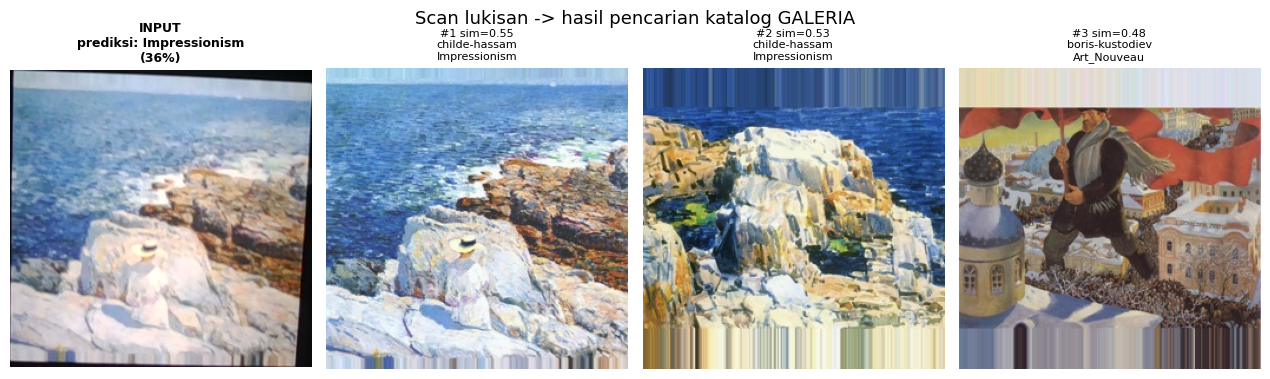

=== PREDIKSI STYLE ===
  Impressionism             35.8%
  Symbolism                 30.0%
  Art_Nouveau               24.3%

=== KECOCOKAN KATALOG (NOT_FOUND) ===
  -> kemungkinan besar karya ini TIDAK ADA di katalog kami
  #1 sim=0.548 | childe-hassam          | Impressionism          | genre_painting     | wikiart_03375.jpg 
  #2 sim=0.525 | childe-hassam          | Impressionism          | Unknown Genre      | wikiart_04682.jpg 
  #3 sim=0.480 | boris-kustodiev        | Art_Nouveau            | Unknown Genre      | wikiart_01089.jpg 


In [28]:
import cv2
import time

def _auto_detect_bbox(frame_bgr, min_area_frac=0.04, max_area_frac=0.92):
    """Heuristik: cari kotak pembungkus area paling TERANG vs latar (bukan
    model AI -- threshold Otsu + contour klasik). Cocok utk kondisi HP
    menyala di ruangan gelap (kontras tinggi). Return (x,y,w,h) atau None."""
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (7, 7), 0)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    h_frame, w_frame = frame_bgr.shape[:2]
    frame_area = h_frame * w_frame
    best, best_area = None, 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area_frac * frame_area or area > max_area_frac * frame_area:
            continue
        if area > best_area:
            best_area = area
            best = cv2.boundingRect(cnt)   # (x, y, w, h)
    return best


def live_scan(cam_index=0, infer_every_n_frames=20, top_k=3):
    win = "GALERIA - Live Visual Search"
    cap = cv2.VideoCapture(cam_index, cv2.CAP_DSHOW)  # CAP_DSHOW: lebih stabil di Windows
    if not cap.isOpened():
        print("Kamera tidak bisa dibuka. Coba cam_index=1 (kalau ada >1 kamera),")
        print("atau cek Settings > Privacy > Camera (izin akses kamera utk aplikasi Desktop/Python).")
        return

    # --- state drag ROI manual (cadangan kalau auto-detect meleset) ---
    drag = {"active": False, "dragging": False, "start": None, "end": None}

    def on_mouse(event, x, y, flags, param):
        if not drag["active"]:
            return
        if event == cv2.EVENT_LBUTTONDOWN:
            drag["dragging"] = True
            drag["start"] = (x, y)
            drag["end"] = (x, y)
        elif event == cv2.EVENT_MOUSEMOVE and drag["dragging"]:
            drag["end"] = (x, y)
        elif event == cv2.EVENT_LBUTTONUP:
            drag["dragging"] = False
            drag["end"] = (x, y)

    cv2.namedWindow(win)
    cv2.setMouseCallback(win, on_mouse)

    print("Kamera aktif. Kotak hijau = area terdeteksi otomatis.")
    print("a=toggle auto-detect | r=pilih manual (drag mouse) | f=full-frame | "
          "SPASI=prediksi ulang | s=simpan | q=keluar")
    frame_i = 0
    last_result = None
    auto_mode = True
    auto_box = None      # kotak auto-detect terakhir (biar tidak lompat2 tiap frame)
    roi = None           # kotak manual (dari drag), dipakai kalau auto_mode False

    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            print("Gagal baca frame kamera."); break
        frame_i += 1
        h_frame, w_frame = frame_bgr.shape[:2]

        force = False
        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break
        elif key == ord("s"):
            path = resolve_path(f"outputs/webcam_capture_{int(time.time())}.jpg")
            cv2.imwrite(str(path), frame_bgr)
            print("disimpan:", path)
        elif key == ord(" "):
            force = True
        elif key == ord("f"):
            auto_mode = False
            roi = None
            drag["active"] = False
            force = True
            print("-> full-frame (auto & manual dimatikan)")
        elif key == ord("a"):
            auto_mode = not auto_mode
            if auto_mode:
                drag["active"] = False
            force = True
            print("-> auto-detect", "AKTIF" if auto_mode else "NONAKTIF")
        elif key == ord("r"):
            auto_mode = False
            drag["active"] = True
            drag["dragging"] = False
            drag["start"] = drag["end"] = None
            print("-> mode pilih manual: klik-tahan-geser-lepas mouse di jendela video")

        # ROI manual terkonfirmasi begitu mouse dilepas
        if drag["active"] and not drag["dragging"] and drag["start"] and drag["end"]:
            x0, y0 = drag["start"]; x1, y1 = drag["end"]
            x0, x1 = sorted((max(0, min(x0, w_frame)), max(0, min(x1, w_frame))))
            y0, y1 = sorted((max(0, min(y0, h_frame)), max(0, min(y1, h_frame))))
            if x1 - x0 > 15 and y1 - y0 > 15:
                roi = (x0, y0, x1 - x0, y1 - y0)
                force = True
                print(f"-> area manual dikonfirmasi: {roi}")
            drag["active"] = False
            drag["start"] = drag["end"] = None

        # auto-detect tiap frame (murah, cuma threshold+contour) kalau mode aktif
        effective_roi = None
        if auto_mode:
            det = _auto_detect_bbox(frame_bgr)
            if det is not None:
                auto_box = det
            effective_roi = auto_box
        else:
            effective_roi = roi

        crop_bgr = frame_bgr
        if effective_roi is not None:
            x, y, w, h = effective_roi
            crop_bgr = frame_bgr[y:y + h, x:x + w]

        if crop_bgr.size and (force or frame_i % infer_every_n_frames == 0):
            rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
            img_pil = Image.fromarray(rgb)
            try:
                last_result = _predict_pil(img_pil, top_k=top_k, transform=live_tf)
            except Exception as e:
                print("prediksi gagal:", e)

        display = frame_bgr.copy()
        if drag["active"] and drag["dragging"] and drag["start"] and drag["end"]:
            cv2.rectangle(display, drag["start"], drag["end"], (0, 255, 255), 2)   # kotak lagi digambar manual
        elif auto_mode and auto_box is not None:
            x, y, w, h = auto_box
            cv2.rectangle(display, (x, y), (x + w, y + h), (0, 255, 0), 2)         # hijau = auto
        elif (not auto_mode) and roi is not None:
            x, y, w, h = roi
            cv2.rectangle(display, (x, y), (x + w, y + h), (255, 0, 255), 2)       # magenta = manual
        if drag["active"] and not drag["dragging"]:
            cv2.putText(display, "MODE PILIH MANUAL: drag mouse di video ini", (12, 28),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
        if last_result is not None:
            style, p = last_result["style_prediction"][0]
            top_match = last_result["catalog_matches"][0]
            hit = top_match["similarity"] > 0.7
            mode_tag = "[auto]" if auto_mode else ("[manual]" if roi is not None else "[full-frame]")
            y0 = 56 if not (drag["active"] and not drag["dragging"]) else 84
            cv2.putText(display, f"Style (tebakan) {mode_tag}: {style} ({p*100:.0f}%)", (12, y0),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.58, (0, 255, 255), 2)
            cv2.putText(display, f"Katalog: {top_match['artist_name']} | {top_match['style_name']}", (12, y0 + 26),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0) if hit else (0, 165, 255), 2)
            cv2.putText(display, f"sim={top_match['similarity']:.2f} {'<- KEMUNGKINAN SAMA' if hit else ''}",
                       (12, y0 + 50), cv2.FONT_HERSHEY_SIMPLEX, 0.52, (0, 255, 0) if hit else (0, 165, 255), 2)
        cv2.putText(display, "a=auto  r=manual  f=full-frame  SPASI=ulang  s=simpan  q=keluar",
                   (12, h_frame - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)

        cv2.imshow(win, display)

    cap.release()
    cv2.destroyAllWindows()
    return last_result

# jalankan (buka jendela kamera) -- kotak hijau otomatis mengikuti area terang (lukisan di layar HP):
last_live_result = live_scan()
if last_live_result is not None:
    show_result(last_live_result, save_path=resolve_path("outputs/demo_live_last.png"))

## 7. Catatan

- **Prediksi style** = tebakan classifier (pretext task), akurasi keseluruhan
  ~78% -- bisa salah, terutama Post-Impressionism/Expressionism (lihat
  confusion matrix `01_train.ipynb`).
- **Kecocokan katalog** = pencarian nearest-neighbor embedding, bukan tebakan
  kelas. Similarity tinggi (>0.7, kalibrasi kasar -- sesuaikan setelah lihat
  beberapa contoh) berarti kemungkinan besar itu KARYA YANG SAMA (atau
  reproduksinya) -- ini yang menjawab "siapa pelukisnya" & "info lengkap",
  diambil langsung dari `metadata.csv` katalog, bukan ditebak model.
- Kalau similarity SEMUA hasil rendah -> lukisan itu **kemungkinan tidak ada**
  di katalog GALERIA (wajar, di produksi nanti katalognya jauh lebih besar
  dari 5.659 karya WikiArt yang kita pakai untuk riset ini).
- Ganti `IMAGE_PATH` di sel 4 untuk coba gambar lain -- dari dataset atau dari
  luar (folder mana saja di laptop kamu).